# SeaBASS data
all chlorophyll data on seabass was bulk downloaded from https://seabass.gsfc.nasa.gov/search#bio

## Download Data
The SeaBASS chlorophyll datasets are large, and so to manage data sizes, Chlorophyll data was downloaded in regional sections. 

Data was limited to dates from 2000/01/01 - 2024/04/28, products included were Chl and HPLC, and the regional sections were limited based on the following coordinates: 
- boudries for East Coast: 47.11N - 23.87S  -83.67W - -69.26E
- boundries for West Coast 53N 19S, -131W -111E
- boundries for Gulf Coast: 31N - 18S  -100W - -79.5E
- boundries for Hawaii: -180W -150E, 25N 0S
- boundries for Alaska: -180W -136, 87N 42S

In the end, you'll have seperate folders for each region:

![seabass_regions](images/sb_regions.png)

## Turn raw .sb files into workable dataframes
The SB_support code found on the SeaBASS website (https://seabass.gsfc.nasa.gov/wiki/Getting_Started#Python%20reader) can be used to read in the .sb files. 

These next def loops are used to gather all folder names in each of the SeaBASS folders downloaded, and then gathering all files that end in .sb in those folders

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
import datetime as dt
from matplotlib import ticker
import warnings
warnings.filterwarnings('ignore')
#import SB_support as sb 
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker
import cartopy.crs as ccrs


In [ ]:
def get_folder_names(folder_path): 
  """
  Returns a list of folder names in the given directory.
  """
  folder_names = []
  for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isdir(item_path):
      folder_names.append(item)
  return folder_names

def get_files(dir): 
    """
     Gather name of all .sb files in a folder 
    """
    file_list = []
    for root, _, files in os.walk(dir):
        for file in files:
            if file.endswith(".sb"):
                file_list.append(os.path.join(root, file))
    return file_list

In order to reduce the size of each dataset, the variable selected_columns is used to only save the needed variables that might be present in the files. All variables in selected_columns after 'chl_a' are included to help us detect if the chlorophyll is HPLC or not. 

In [ ]:
selected_columns =['lat','lon','year','month','day','hour','minute','second','time','date','datetime','depth','station', 'chl','chl_a', 'Allo', 'alpha-beta-car', 'anth', 'asta', 'bchl_a',
                   'beta-beta-car', 'beta-epi-car', 'beta-psi-car', 'but-fuco', 'cantha', 'chl_a_allom', 'chl_a_prime','chl_b', 'chl_c', 'chl_c1', 
                   'chl_c1c2', 'chl_c2', 'chl_c3', 'chlide_a', 'chlide_b', 'chors_id', 'croco', 'diadchr', 'diadino', 'diato', 'dino', 'dv_chl_a', 'dv_chl_b',
                   'echin', 'epi-epi-car', 'et-8-carot', 'et-chlide_a', 'et-chlide_b', 'fuco', 'gyro', 'hex-fuco', 'hex-kfuco', 'hpl_id', 'hplc_gsfc_id', 'lut', 
                   'lyco', 'me-chlide_a','me-chlide_b', 'mg_dvp', 'monado', 'mv_chl_a', 'mv_chl_b', 'neo', 'p-457', 'perid', 'phide_a', 'phide_b', 'phide_c',
                   'phytin_a','phytin_b', 'phytin_c',' phytyl-chl_c', 'pras', 'pyrophide_a', 'pyrophytin_a', 'pyrophytin_b', 'pyrophytin_c', 'siphn', 'siphx', 
                   'tot_chl_a', 'tot_chl_b', 'tot_chl_c', 'vauch', 'viola', 'zea']

Within each regional folder, there can be several requested_files. This for example, is the folder structure inside the east_coast folder:
![seabass_request](images/sb_request_file.png)

**For each resquested_files_# in the folder** the next two code blocks need to be run and the path_to_folder variable needs to be changed. This code turns .sb files in each of the folders into a dataframe with metadata appended on each row 

In [ ]:
path_to_folder = r'west_coast\requested_files_2\requested_files' #NOTE: there are usually multiple requested_files, this is where you would manually loop thru them
all_folders = get_folder_names(path_to_folder)

for folders in range(len(all_folders)): #for each affiliation folder in all_folders
    f_list1 =   path_to_folder +'\\'+str(all_folders[folders]) #create path to that specific folder 
    f_list = get_files(f_list1) #gather all .sb files in f_list1
    print(str(all_folders[folders]))
    dfs = []  # list to collect all processed DataFrames
    for file in f_list: #for each .sb file
        data1 = sb.readSB(filename=file, no_warn=True) #read it using readSB from the seabass website
        data2 = data1.data #append the data 
        df = pd.DataFrame.from_dict(data2, orient='index').T #turn data into dataframe
        dt = None  # initialize datetime variable
        #Detect the datetime columns in the dataframe and create single datetime column 
        if all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute', 'second']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']]) #if all 6 time values, create datetime
        elif all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        elif all(col in df.columns for col in ['year', 'month', 'day', 'time']):
            df['hour'] = df['time'].astype(str).str[:-6].astype(int) #if just time, seperate into hour, min, sec 
            df['minute'] = df['time'].astype(str).str[-5:-3].astype(int)
            df['second'] = df['time'].astype(str).str[-2:].astype(int)
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        elif all(col in df.columns for col in ['date', 'time']):
            df['year'] = df['date'].astype(str).str[:4].astype(int)
            df['month'] = df['date'].astype(str).str[4:6].astype(int)
            df['day'] = df['date'].astype(str).str[6:8].astype(int)
            time_strs = df['time'].astype(str) #some files have time as HH:mm, some as HH:mm:ss, so this accounts for both
            if time_strs.str.contains(":").all() and time_strs.str.count(":").eq(2).all():  #determine format based on string length or presence of ":"
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = time_strs.str.split(":").str[2].astype(float).astype(int)
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
            elif time_strs.str.contains(":").all() and time_strs.str.count(":").eq(1).all():
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = 0
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        else: #if none of the above is deteted, skip for now, we'll create it later
            dt = pd.NaT
        df.insert(0, 'datetime', dt) #insert datetime column into df
        columns_to_keep = [col for col in df.columns if col in selected_columns or col == 'datetime'] #only keep whatever columns are in selected_columns
        df_filtered = df[columns_to_keep]
        header = pd.DataFrame.from_dict(data1.headers, orient='index').T #create metedata header from dictionary and repeat it to match lenth of dataset
        header_repeated = pd.concat([header] * len(df_filtered), ignore_index=True)
        # Combine data and metadata
        combined = pd.concat([df_filtered.reset_index(drop=True), header_repeated], axis=1)
        combined = combined.loc[:, ~combined.columns.duplicated()]
        dfs.append(combined)
    #final concatenation
    globals()[str(all_folders[folders])] = pd.concat(dfs, ignore_index=True) #append all files in that specific affiliation file toether 

chl_columns =['chl','chl_a'] #for reducing rows without these in it (without ,'chl_experiment','chl_stimf')
for names in all_folders: #for each affilitation dataframe
    print(names)
    chl_cols=[col for col in (globals()[names]).columns if col in chl_columns] #detect the chlorophyll columns present 
    (globals()[names]).dropna(subset=chl_cols, how='all', inplace=True) #if rows in the chl columns empty, remove 

#for any remaining empty datetime, manually create it from the metadata date 
for names in all_folders:
    print(names)
    (globals()[names])['time_flag']='no' #create a flag stating if datetime populated from metadata, initiate as no 
    if 'datetime' not in (globals()[names]).columns: #if the dataframe does not have datetime column, create one
        (globals()[names])['datetime']=pd.NaT
    for idx in (globals()[names]).index: #loop through each row 
        try:
            if pd.isna((globals()[names]).at[idx, 'datetime']) and (globals()[names]).at[idx, 'start_date'] == (globals()[names]).at[idx, 'end_date']: 
                #sometimes, start_date and end_date are concerning the start and end of the cruise/project, not that specific data recording. so only enter if loop if start_date = end_date
                #extract strings
                date_str = str((globals()[names]).at[idx, 'end_date'])  # e.g. "20240520"
                time_str = str((globals()[names]).at[idx, 'end_time'])  # e.g. "14:30:00.000"
                #parse date and time parts
                year = int(date_str[:4])
                month = int(date_str[4:6])
                day = int(date_str[6:8])
                hour = int(time_str[:-11])
                minute = int(time_str[-10:-8])
                second = int(float(time_str[-7:-5]))  # Handles "00.000"

                dt = datetime(year, month, day, hour, minute, second)
                (globals()[names]).at[idx, 'datetime'] = dt #populate that specific datetime row with dt
                (globals()[names]).at[idx, 'time_flag'] = 'yes' #turn the time_flag to yes
        except Exception as e:
            # If there's a parsing problem, skip gracefully
            print(f"Row {idx} failed — start_date: {date_str}, end_time: {time_str}")
            (globals()[names]).at[idx, 'time_flag'] = f'error: {e}'

#if lat or lon are empty, populate with the metadata      
for names in all_folders:
    (globals()[names])['coord_flag'] = 'no' #create a flag stating if coordinates populated from metadata, initiate as no 
    if 'lat' not in (globals()[names]).columns: #if lat and lon not in columns, create an empty column
        (globals()[names])['lat']=pd.NA
        (globals()[names])['lon']=pd.NA
    for idx in (globals()[names]).index: #for each row
        if pd.isna((globals()[names]).at[idx, 'lat']) and (globals()[names]).at[idx, 'north_latitude'] ==(globals()[names]).at[idx, 'south_latitude']:
            #sometimes, north_lat and south_lat show the total boundry of the project rather than specific point. so only append if they equal each other
            (globals()[names]).at[idx, 'lat'] = float((globals()[names]).north_latitude[idx][:-5]) #pull latitude value out of north_lat
            (globals()[names]).at[idx, 'coord_flag'] = 'yes' #turn flag to yes
        if pd.isna((globals()[names]).at[idx, 'lon']) and (globals()[names]).at[idx, 'west_longitude'] ==(globals()[names]).at[idx, 'east_longitude']:
            (globals()[names]).at[idx, 'lon'] = float((globals()[names]).west_longitude[idx][:-5])
            (globals()[names]).at[idx, 'coord_flag'] = 'yes'   

## HPLC Flags
In order to detect if HPLC is recorded or not, 3 methods are used. 
1. If chl_a is in the dataframe, then assume HPLC
2. if chl_a is not in the dataframe and no other columns in hplc_hints are found, then assume no HPLC is recorded.
3. if chl_a is not in the datafrme **BUT** another variable that can only be recorded with HPLC methods **IS** recorded, then assume chl_a was mislabled and mark chl as HPLC. 

In [ ]:
#strictly speaking, seabass marks chl as non-hplc and chl_a as hplc. however, sometimes hplc data is entered as chl. so to better detect if 
#the data is hplc or not, hplc_hints can be used to see if other HPLC exclusive variables were collected. 
hplc_hints =['Allo', 'alpha-beta-car', 'anth', 'asta', 'bchl_a', 'beta-beta-car', 'beta-epi-car', 'beta-psi-car', 'but-fuco', 'cantha', 
             'chl_a', 'chl_a_allom', 'chl_a_prime','chl_b', 'chl_c', 'chl_c1', 'chl_c1c2', 'chl_c2', 'chl_c3', 'chlide_a', 'chlide_b',
             'chors_id', 'croco', 'diadchr', 'diadino', 'diato', 'dino', 'dv_chl_a', 'dv_chl_b', 'echin', 'epi-epi-car', 'et-8-carot',
             'et-chlide_a', 'et-chlide_b', 'fuco', 'gyro', 'hex-fuco', 'hex-kfuco', 'hpl_id', 'hplc_gsfc_id', 'lut', 'lyco', 'me-chlide_a',
             'me-chlide_b', 'mg_dvp', 'monado', 'mv_chl_a', 'mv_chl_b', 'neo', 'p-457', 'perid', 'phide_a', 'phide_b', 'phide_c', 'phytin_a',
             'phytin_b', 'phytin_c',' phytyl-chl_c', 'pras', 'pyrophide_a', 'pyrophytin_a', 'pyrophytin_b', 'pyrophytin_c', 'siphn', 'siphx', 
             'tot_chl_a', 'tot_chl_b', 'tot_chl_c', 'vauch', 'viola', 'zea'] #columns that hint towards hplc 
      
# create HPLC flag
#if chl_a was recorded, flag as hplc.
#if chl is present WITHOUT chl_a, BUT other columns in hplc_hints are present, mark as suspected HPLC (2)
for names in all_folders:
    df = globals()[names] 
    df['HPLC'] = 1 #assume not hplc unless i tell it otherwise
    if 'chl_a' in df.columns:
        df.loc[df['chl_a'].notna(), 'HPLC'] = 0 #if chl_a in columns and is not empty, mark as hplc
    existing_hints = [col for col in hplc_hints if col in df.columns] #first, are there any hplc columns in the dataframe
    if 'chl' in df.columns:
        cond_chl_exists = df['chl'].notna() #if chl is not empty
        if 'chl_a' in df.columns: #if chl_a is either is empty or doesn't exist 
            cond_chla_empty = df['chl_a'].isna()
        else:
            cond_chla_empty = True 
        if existing_hints: #if the dataframe has these columns in it 
            cond_hints_exist = df[existing_hints].notna().any(axis=1) #pull these columns
        else:
            cond_hints_exist = False
        final_mask = cond_chl_exists & cond_chla_empty & cond_hints_exist #if chl is recorded AND chl_a is empty AND there are hplc_hint columns
        df.loc[final_mask, 'HPLC'] = 2 #flag as suspected hplc
        
        #you can stop above, the below is to detect when and where the suspected flags occur 
        flagged_rows = df[final_mask]
        for index, row in flagged_rows.iterrows(): #for the rows that agree with the final mask
            found_cols = [col for col in existing_hints if pd.notna(row[col])]
            print(f"DF: {names} | Row: {index} | Flagged as HPLC (2). Found hints: {found_cols}")
    
dfs_to_concat = [(globals()[names]) for names in all_folders] #concatinate the dataframes in all_folders

Once dfs_to_concat has run, save all the dataframes in that folder to a dataframe, and then repeat for the next however many requested_files_# you have. Since east_coast has three requested_files_#, each folder is saved to east1, east2, and east3 respectively. 

Once all folders are run and concatinated, the dataframe is reduced to only the columns relevant to the project and subset to a North America shapefile

In [ ]:
#For example there are 3 requested_files in the east coast section 
east1 = pd.concat(dfs_to_concat, ignore_index=True) #save dfs_to_concat to single dataframe. STOP HERE and repeat if you have multiple requested files
east2 = pd.concat(dfs_to_concat, ignore_index=True)
east3 = pd.concat(dfs_to_concat, ignore_index=True)
east_coast = pd.concat([east1,east2,east3])
east_coast=east_coast[['datetime', 'lat', 'lon', 'chl', 'station', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise', 'data_type',
        'water_depth', 'measurement_depth', 'water_depth ', 'depth', 'identifier_product_doi', 'instrument_name', 'instrument', 'time_flag', 
        'coord_flag',  'hplc_lab', 'chl_a', 'sequence_number','sample','data_file_name','HPLC']]

shp = gpd.read_file('combined_coastline.shp')
gdf = gpd.GeoDataFrame(east_coast, geometry=gpd.points_from_xy(east_coast.lon, east_coast.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
east_coast = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
east_coast = east_coast.drop(columns=columns_to_drop)
east_coast= east_coast.reset_index(drop=True)

Repeat the code from  "path_to_folder =" to "east_coast= east_coast.reset_index(drop=True)" for each regional folder. In my case, I repeated it for the East Coast, West Coast, Gulf Coast, Hawaii, and Alaska, resulting in 5 dataframes (df)

Each Dataframe (df) is then reduced to only data post 1999. Additionally, depth is populated depending on the datatype from the metadata.

In [ ]:
df = df[df['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 
df['depth'] = np.where((df['depth'].isna()) & (df['data_type']=='flow_thru'), df['measurement_depth'], df['depth'])
df['depth'] = np.where((df['depth'].isna()) & (df['data_type']=='mooring'), df['water_depth'], df['depth'])

## Triplicate flags
In order to detect in a sample was recorded in triplicates, two methods are employed.
1. The number of unique datetime, lat, and lon points are recorded and saved to a column of the dataframe (called freq_uniq). if freq_uniq ==3, then there are three unique samples recorded at that specific datetime, lat, and lon, and so we can assume it's a triplicate.
2. Sometimes, a project recordes the exact time each tripliate sample is recorded, so for example a sample will be recorded at 3:25, 3:30, and 3:33. In order to detect these triplicate samples, all unique date hours, lat, and lon are recorded as the column name freq_hour. IF freq_uniq ==1 and freq_hour ==3, assume the sample was recorded in triplicate.

Here's an example of the above methods in action: 
![seabass_trip](images/triplicate_example.png)


In [ ]:
#FLAG for triplicates 
counts_series = df[['datetime','lat','lon']].value_counts() #count how many unique datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
df = pd.merge(df, counts_df, on=['datetime','lat','lon'], how='left') #add frequency column to original dataframe
df['date_hour'] = df['datetime'].dt.strftime('%Y-%m-%d %H')#some places have 3 different times close to gether but that's bc of recording each time for triplicate (3:00, 3:05, 3:10 )
counts_series = df[['date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
df = pd.merge(df, counts_df, on=['date_hour','lat','lon'], how='left') #add frequency column to original dataframe

df['triplicate'] = 1 #assume bad unless otherwise said
df.loc[df['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
df.loc[(df['freq_uniq'] == 1) &(df['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime recorded and only 3 for datehour, assume triplicate 


In [ ]:
#remove depths below 150
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df = df[df['depth'] <=150].reset_index(drop=True)

#save the same columns for all files
df=df[['datetime', 'lat', 'lon', 'chl', 'chl_a','depth','experiment', 'data_type','station', 'affiliations','investigators', 'contact',
           'cruise', 'identifier_product_doi', 'time_flag','coord_flag', 'data_file_name', 'HPLC', 'triplicate']]


Concatinate all the folders into one dataframe and drop any duplicates. 

In [ ]:
all_data = pd.concat([alas,east, gom,hawaii,west], axis=0) 
all_data = all_data.drop_duplicates()

## Data type detection

Sometimes, the SeaBASS metadata variable 'data_type' is not completely true. For example, it's hard to tell if 'cast' means an instrument deployed on a cast that recorded flourecence data, of if data was collected from a cast rosette, which can then be confused with bottle type.

For this algorithm, we care less about the specific data_type used to gather chl, as long as the chl is not in-vivo. And an easy way of detecting if it's in-vivo or not is by looking at the spatial and temporal resolution of each datatype to see if it was floursecence or not. 

To do this, we'll create a a flagging system *(0=good, 1=bad, 2=undetermined)* that detects:
- **diff_space**: the spatial station dfference between stations (how far apart are each station?)
- **diff_s**: the time between each sample's recording (was the sample taken every 10 mins? 10 seconds?)
- **num_s**: number of measurments per stations (did 1 station at a specific date record 1000 sample? 10 samples?)
- **data_flag**: flag for the SeaBASS data_type (what is the data_type SeaBASS says it is?)
- **s_flag**: the spatial resolution between samples (how far apart are each sample's lat and lon?) 
- **d_flag**: the depth resolution (how far apart is each depth sample?)
- **t_flag**: the temporal resolution (how much time is between each sample?)
- **decision**: Final flag based off of other flags values. If 0, not in-vivo. if 1, assume in-vivo. if 2, suspect/ unsure

For the most part, the flags are triggered to bad if:
- **s_flag**: the space between samples is less than 1km 
- **d_flag**: the change in depth between samples is less than 1m 
- **t_flag**: the time between samples is less than 10 mins for flow_thru and pigment, 1 hour for cast and bottle

Below is a snippit of the flagging code "SeaBass_flags2" that is used to estimate if the data is in-vivo or not. Bear in mind this specific snippet is just for data_type = pigment. The specific limits vary slightly depending on the data_type (for example, I am more strict with flow thru data since it's most likely in vivo than with bottle). Please refer to the code in the github for the complete code. 

In [ ]:
def measure(lat1, lon1, lat2, lon2): #function to convert the difference between two lat and lon points to km
    R = 6378.137 #Radius of earth in KM
    dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
    dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
    a = np.sin(dLat/2) * np.sin(dLat/2) +np.cos(lat1 * np.pi/ 180) * np.cos(lat2 * np.pi / 180) *np.sin(dLon/2) * np.sin(dLon/2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = R * c;
    return d * 1000 #; // meters

a=df.copy()
a['t_flag']=0 #initialize temporal resolution flag, 0=good, 1= bad (less than 1hour),2=flag (time is 0 i.e repeated)
a['s_flag']=0 #initialize spatial resolution flag, 0=good, 1= bad (less than 2km),2=flag (lat/lon is 0 i.e repeated)
a['data_flag'] = 0 #column to populate with datatypes as values for organization
a['d_flag'] = 0 #initialize depth flag, 0=good, 1=bad (less than 5m), 2=flag
a['decision'] = 2 #ultimate decision flag inidcating whether to keep or toss data point (0=good, 1=bad,2=flag)
a.loc[a['data_type'].str.contains('bottle'), 'data_flag'] = 4
a.loc[a['data_type'].str.contains('cast'), 'data_flag'] = 3 
a.loc[a['data_type'].str.contains('flow_thru'), 'data_flag'] = 2
a.loc[a['data_type'].str.contains('pigment'), 'data_flag'] = 1
if 'station' not in a.columns:
    a['station'] = np.nan
if 1 in a.data_flag.values: #pigment
    p=a.loc[a['data_flag']==1].reset_index(drop=True) 
    #p.dropna(axis=1, how='all', inplace=True) #drop all empty columns
    pp=p.station.unique() #identify number of stations 
    if p.station.empty or len(p)== len(pp): #if the metadata has no stations or every point is a station
        #time flag
        p['diff_time']= p['datetime'].diff()
        p.t_flag=np.where(p['diff_time']< pd.to_timedelta('10 minutes'), 1, p.t_flag) #if delta t is less than 1 hour, flag as bad
        p.t_flag=np.where(p['diff_time']== pd.to_timedelta(0), 2, p.t_flag) #if 0, then just a repeat so not necessarily bad
        #space flag
        c=[]
        for i in range(len(p)-1):
            meters=measure(float(p.lat[i]),float(p.lon[i]),float(p.lat[i+1]),float(p.lon[i+1]))
            c.append(meters)
            #add nan on top to make the list shift down and fit
        c.insert(0,float('nan'))
        p['diff_space']=pd.Series(c)
        p.s_flag=np.where(p['diff_space']< 1000, 1, p.s_flag) #2000m ie 2km
        p.s_flag=np.where(p['diff_space']== 0, 2, p.s_flag) #if 0, then just a multi samples so not necessarily bad
        #add decicion flags
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==0)] = 0 #if both good, then good
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==1)] = 1 #if both bad, then flag bad
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==0)] = 1 
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==1)] = 2 
    #when i first populat the column, it's populated with flag, so all other cases that are not above are flagged
    else: #if the station column is NOT empty i.e stations are recorded or just 1 station
        p.sort_values(['datetime'], inplace=True)        
        pp=p.groupby(['datetime']).size() #Group by datetime i.e station and time
        pp=pd.DataFrame(pp)        
        pp_n=p.groupby(['datetime']).size().reset_index() #group again, this time with datetime in column to manipulate
        pp_n['diff_s'] = pp_n.datetime.diff() #caluclate change in time between each station
        pp_n=pd.DataFrame(pp_n)

        pp['diff_s']=pp_n['diff_s'].to_numpy() #populate pp dataframe with change in station time
        station_count = pp[0] #sample rate i.e how many samples per station
        time_count = pp['diff_s'] #time between stations
        p['diff_time'] = p['datetime'].map(time_count) #Map onto original dataframe
        p['num_s']=p['datetime'].map(station_count) #number of measurments per stations
        #both of these above should trigger t_flag
        p.t_flag=np.where(p['diff_time']< pd.to_timedelta('10 minutes'), 1, p.t_flag)
        p.t_flag=np.where(p['num_s']>1000, 1, p.t_flag) #if the number of measurments at one station is too high i.e sample rate, flag it
        #space flag can be more loose since there are discrete stations, but still tag for high resolution cases
        c=[]
        for i in range(len(p)-1):
            meters=measure(float(p.lat[i]),float(p.lon[i]),float(p.lat[i+1]),float(p.lon[i+1]))
            c.append(meters)    
        c.insert(0,float('nan'))
        p['diff_space']=pd.Series(c)
        p.s_flag=np.where(p['diff_space']< 1000, 1, p.s_flag) #2000m ie 2km
        p.s_flag=np.where(p['diff_space']== 0, 0, p.s_flag) #if 0, then mark as good because diff_time and num_s will stop bad data points
        
        #depth flag
        if 'depth' in p.columns:
            depth_diff =abs(p.depth.diff())#calculate absolute change in depth
            p.loc[p[depth_diff<1].index,'d_flag']=1 #if the change in depth is not large enough
            p.loc[p[depth_diff==0].index,'d_flag']=2 #if the change in depth doesn't move, set as 2, diff_time and num_s will take care of it


        #add decicion flags
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==0) & (p['d_flag']==0)] = 0 #if both good, then good
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==0) & (p['d_flag']==1)] = 1 #if everything else is good but the depth is too short, flag as nad
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==0) & (p['d_flag']==2)] = 0 #if everything else is good and depth repeats, good
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==1) & (p['d_flag']==0)] = 2 #if time per station is ok and depth ok but space no, just flag
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==1) & (p['d_flag']==1)] = 1 #if depth range bad, and space bad, no
        p.decision[(p['t_flag'] ==0) & (p['s_flag'] ==1) & (p['d_flag']==2)] = 2 
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==0) & (p['d_flag']==0)] = 1 #IF TIME IS EVER BAD then the whole thing is bad
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==0) & (p['d_flag']==1)] = 1
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==0) & (p['d_flag']==2)] = 1
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==1) & (p['d_flag']==0)] = 1
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==1) & (p['d_flag']==1)] = 1
        p.decision[(p['t_flag'] ==1) & (p['s_flag'] ==1) & (p['d_flag']==2)] = 1
        if 'diff_space' in p.columns:
            p.decision[(pd.isna(p.diff_time)) & (pd.isna(p.num_s)) & (pd.isna(p.diff_space))] = 1 #if change in time, stations, and change in space all empty, flag bad
else:
    p=pd.DataFrame() #if there is no pigmant data, make empty dataframe to append


Once you run through all dataframes through the seabass_flags2 code, you're seabass chlorophyll dataset is complete! You now have a dataset of all Seabass chlorophyll data, above 150m, post 1999, in North America with flourecence flags, HPLC flags, and triplicate flags. 

P.J. Werdell, S.W. Bailey, G.S. Fargion, C. Pietras, K.D. Knobelspiesse, G.C. Feldman, and C.R. McClain, "Unique data repository facilitates ocean color satellite validation", EOS Trans. AGU 84 , 38, 377 (2003)

## Plots of all data

In [3]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')

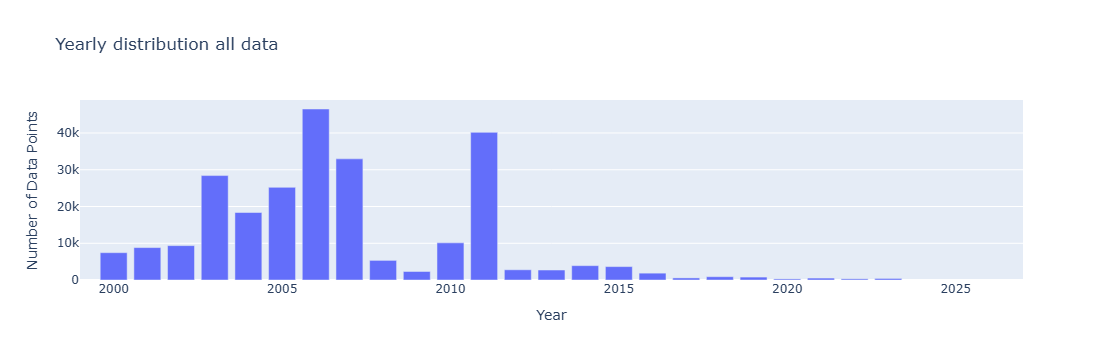

In [4]:
year_test=seabass.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

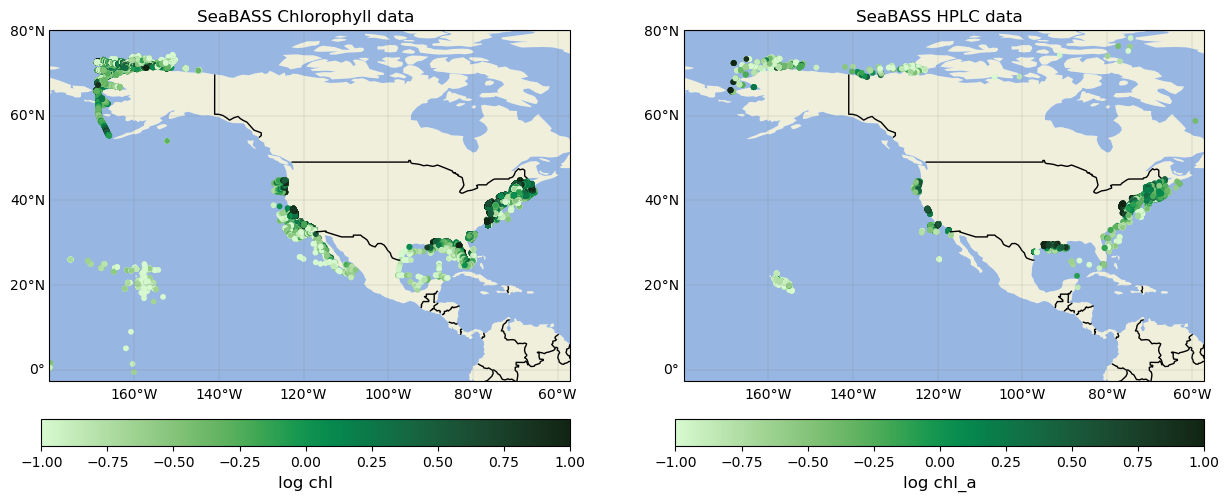

In [5]:
year_test['log_chl']=np.log10(year_test['chl'])
year_test['log_chl_a']=np.log10(year_test['chl_a'])

fig=plt.figure(figsize=(15, 10))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs1.set_title('SeaBASS Chlorophyll data')
axs1.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
axs1.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal', pad=0.05)
cb.set_label('log chl',fontsize=12)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
im=axs2.scatter(year_test.lon,year_test.lat,c=year_test.log_chl_a,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs2.set_title('SeaBASS HPLC data')
axs2.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
axs2.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal', pad=0.05)
cb.set_label('log chl_a',fontsize=12)
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels

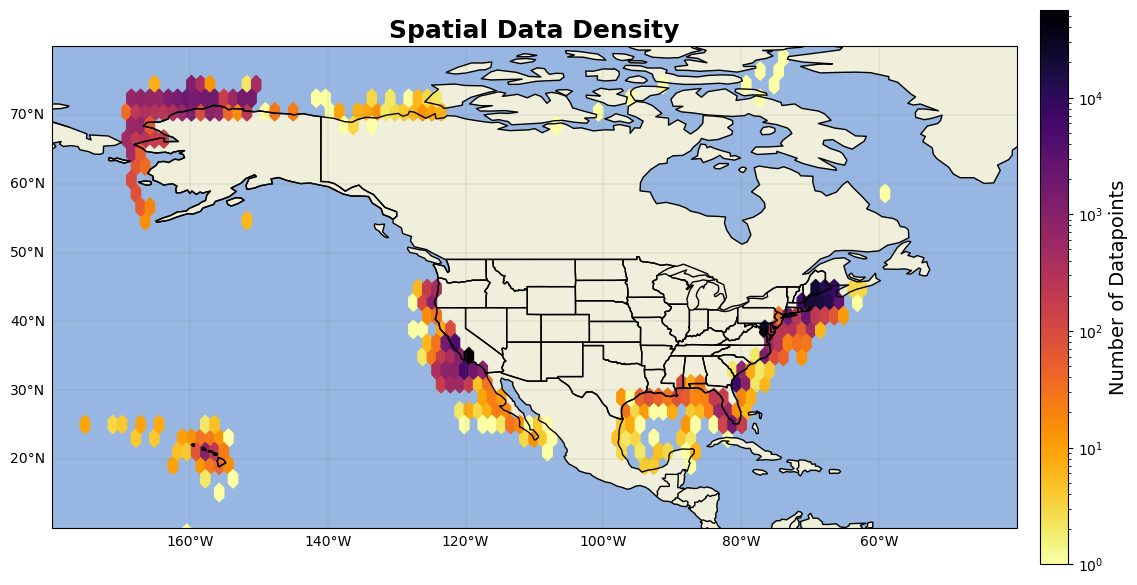

In [11]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(90,20), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()